In [ ]:
# Prathmesh Durge, 23070521109

# Stock Market Prediction using LSTM
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


In [4]:

# 1. Download NASDAQ stock data
# Example: Apple (AAPL)
data = yf.download("AAPL", start="2015-01-01", end="2025-01-01")

# Use closing price
prices = data["Close"].values.reshape(-1, 1)

# 2. Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(prices)


[*********************100%***********************]  1 of 1 completed


In [5]:

# 3. Create sequences
# Use previous 60 days to predict the next day
X = []
y = []

sequence_length = 60

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

# Reshape for LSTM: samples, time steps, features
X = X.reshape(X.shape[0], X.shape[1], 1)

In [6]:

# 4. Split into training and testing data
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [7]:

# 5. Build LSTM model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    LSTM(50),
    Dense(1)
])

model.compile(optimizer="adam", loss="mean_squared_error")

c:\Users\Prathmesh\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:

# 6. Train the model
model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 23s 147ms/step - loss: 0.0054 - val_loss: 9.6112e-04
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 126ms/step - loss: 2.3531e-04 - val_loss: 0.0012
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 132ms/step - loss: 2.2067e-04 - val_loss: 8.9662e-04
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 127ms/step - loss: 2.0499e-04 - val_loss: 9.6304e-04
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 126ms/step - loss: 1.8885e-04 - val_loss: 7.4398e-04
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 146ms/step - loss: 1.9439e-04 - val_loss: 7.9279e-04
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 129ms/step - loss: 1.7012e-04 - val_loss: 6.5971e-04
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 119ms/step - loss: 1.8665e-04 - val_loss: 6.8221e-04
Epoch 9/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 126ms/step - loss: 1.6603e-04 - val_loss: 6.9437e-04
Epoch 10/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step - loss: 1.5230e-04 - val_loss: 5.5431e-04


16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 158ms/step


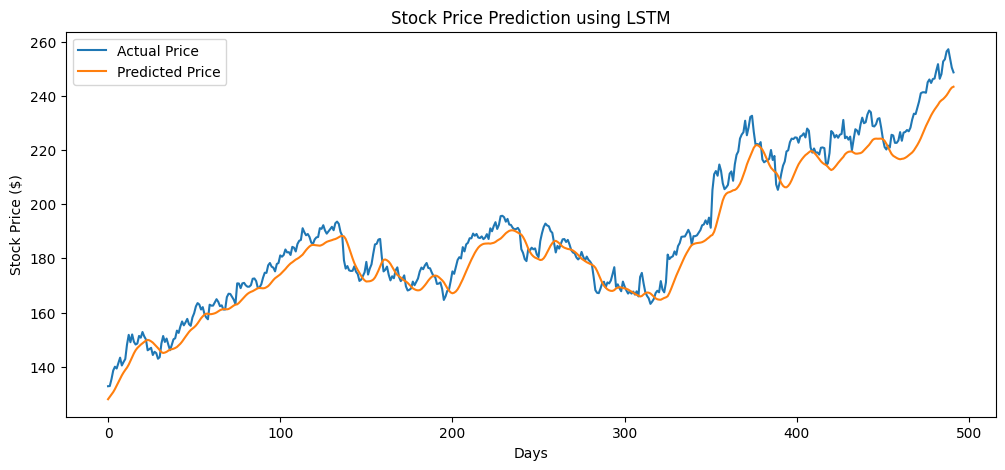

In [9]:

# 7. Predict stock prices
predicted = model.predict(X_test)

# Convert predictions back to original price scale
predicted = scaler.inverse_transform(predicted)
actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# 8. Visualize Actual vs Predicted
plt.figure(figsize=(12, 5))

plt.plot(actual, label="Actual Price")
plt.plot(predicted, label="Predicted Price")

plt.title("Stock Price Prediction using LSTM")
plt.xlabel("Days")
plt.ylabel("Stock Price ($)")
plt.legend()
plt.show()